**Logistic Regression - Binary**

Logistic regression is appropriate when the dependent/target variable is dichotomous (binary). Like all regression analyses, the logistic regression is a predictive analysis. Logistic regression is used to model data and to explain the relationship between one binary dependent/target variable and one or more nominal, ordinal, interval or ratio-level independent/input variables.

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFE 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

import warnings 
warnings.filterwarnings("ignore")

In [2]:
# Importing the dataset
dataset = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 7 - Logistic Regression/Social_Network_Ads.csv')
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
dataset.shape

(400, 5)

**EDA**

Text(0.5, 1.0, 'Histogram of Age')

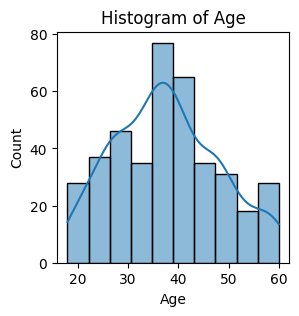

In [4]:
plt.figure(figsize = (3,3))
sns.histplot(dataset['Age'], kde = True)
plt.title('Histogram of Age')

Text(0.5, 1.0, 'Histogram of Expected Salary')

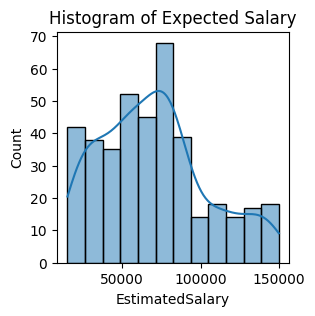

In [5]:
plt.figure(figsize = (3,3)) 
sns.histplot(dataset['EstimatedSalary'], kde = True)
plt.title('Histogram of Expected Salary')

In [6]:
dataset['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

<Axes: xlabel='Purchased', ylabel='count'>

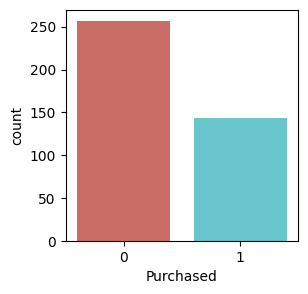

In [7]:
# print(dataset['Purchased'])
import seaborn as sns
plt.subplots(figsize = (3,3))
sns.countplot(x = dataset['Purchased'], palette ='hls')

In [8]:
dataset[['Age', 'EstimatedSalary']].describe()

,Age,EstimatedSalary
count,400.000000,400.000000
mean,37.655000,69742.500000
std,10.482877,34096.960282
min,18.000000,15000.000000
25%,29.750000,43000.000000
50%,37.000000,70000.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [9]:
dataset.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [10]:
x = dataset[dataset.columns[1:4]] 
y = dataset[dataset.columns[4]] 

In [11]:
print(x.columns)
print(x.shape)

Index(['Gender', 'Age', 'EstimatedSalary'], dtype='object')
(400, 3)


In [12]:
y.shape

(400,)

**Data Split**

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

In [14]:
le = LabelEncoder()
x_train['Gender'] = le.fit_transform(x_train['Gender'])
x_test['Gender'] = le.transform(x_test['Gender'])

**OLS Regression Results**

In [15]:
import statsmodels.api as sm
x2 = sm.add_constant(x_train)
est = sm.OLS(y_train, x2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:              Purchased   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     80.35
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           1.18e-38
Time:                        11:08:55   Log-Likelihood:                -128.36
No. Observations:                 320   AIC:                             264.7
Df Residuals:                     316   BIC:                             279.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.9167      0.088    -

**Feature ranking with Recursive Feature Elimination (RFE)**

Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), the goal of recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features. First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through any specific attribute or callable. Then, the least important features are pruned from current set of features. That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached.

In [16]:
logreg = LogisticRegression()
rfe = RFE(logreg, n_features_to_select = 5, step = 1)
rfe = rfe.fit(x_train, y_train.values.ravel())
print(rfe.support_) 
print(rfe.ranking_)

[ True  True  True]
[1 1 1]


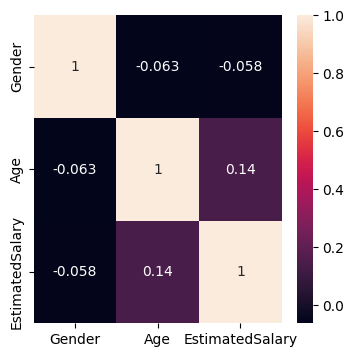

In [17]:
sns.heatmap(x_train.corr(), annot = True)
fig = plt.gcf()
fig.set_size_inches(4,4)

**Logistic Regression - Base Model with imbalance dataset**

In [18]:
# Build Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

log_reg.get_params() 

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [19]:
# Predicting the Test set results
y_pred = log_reg.predict(x_test)

In [20]:
# Model Evaluation Measures
print ('Accuracy: ', accuracy_score(y_test, y_pred)*100,'%')
print ('Precision: ', precision_score(y_test, y_pred, average = 'weighted')) 
print ('Recall: ', recall_score(y_test, y_pred, average = 'weighted'))
print ('F1 Score: ', f1_score(y_test, y_pred, average = 'weighted'))
print ('\n Classification Report:\n', classification_report(y_test, y_pred))

Accuracy:  88.75 %
Precision:  0.8897406559877956
Recall:  0.8875
F1 Score:  0.8845655693470048

 Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[50,  2],
       [ 7, 21]])

Text(0.5, 1.0, 'Confusion Matrix')

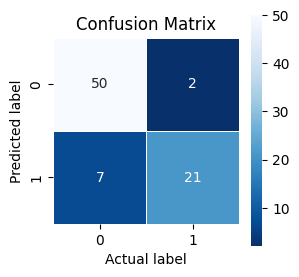

In [22]:
plt.figure(figsize = (3,3))
sns.heatmap(cm, annot = True, linewidths = 0.5, square = True, cmap = 'Blues_r')
plt.xlabel('Actual label')
plt.ylabel('Predicted label')
plt.title("Confusion Matrix")

**Plot ROC Curve**

A useful tool when predicting the probability of a binary outcome is the Receiver Operating Characteristic curve, or ROC curve.

It is a plot of the false positive rate (x-axis) versus the true positive rate (y-axis) for a number of different candidate threshold values between 0.0 and 1.0. Put another way, it plots the false alarm rate versus the hit rate.

The true positive rate is calculated as the number of true positives divided by the sum of the number of true positives and the number of false negatives. It describes how good the model is at predicting the positive class when the actual outcome is positive.

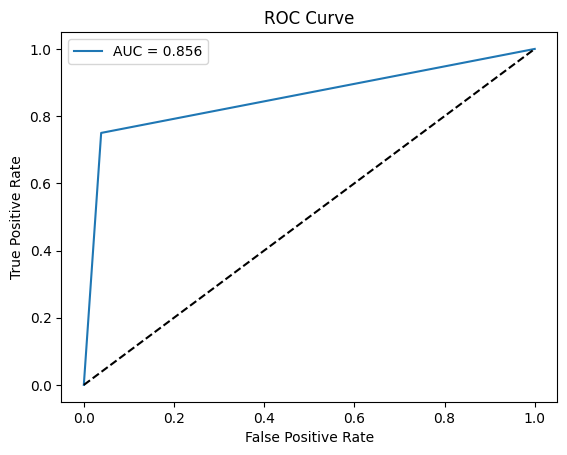

In [23]:
def plot_roc(y_test, y_pred):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    plt.plot(fpr, tpr, label = f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], 'k--')  # diagonal
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

plot_roc(y_test, y_pred)

**Class Balancing**

* A problem with imbalanced classification is that there are too few examples of the minority class for a model to effectively learn the decision boundary. 
* One way to solve this problem is to oversample the examples in the minority class. This can be achieved by simply duplicating examples from the minority class in the training dataset prior to fitting a model. This can balance the class distribution but does not provide any additional information to the model.
* The most widely used approach to synthesizing new examples is called the Synthetic Minority Oversampling TEchnique, or SMOTE

Counter({0: 205, 1: 205})


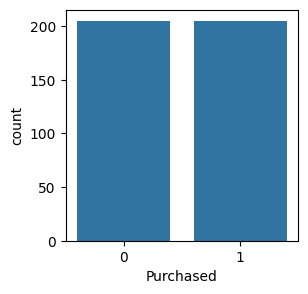

In [24]:
# %pip install imbalanced-learn
from collections import Counter
from imblearn.over_sampling import SMOTE
x_train_b, y_train_b = SMOTE().fit_resample(x_train, y_train)

plt.subplots(figsize = (3,3))
sns.countplot(x = y_train_b)
print(Counter(y_train_b))

**Hyper Parameter Tuning using balanced dataset**

In [25]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

In [26]:
from sklearn.model_selection import GridSearchCV
from numpy import arange

model_LR = LogisticRegression()

parameters = dict()
parameters['penalty'] = ['l1', 'l2', 'elasticnet'] # Penalization (Regularization). Deprecated since version 1.8: penalty was deprecated in version 1.8 and will be removed in Sklearn 1.10.
parameters['C'] = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 7, 10] # Inverse regularization parameter - A control variable that retains strength modification of Regularization by being inversely positioned to the Lambda regulator. C = 1/λ
parameters['solver'] = ['liblinear', 'newton-cg', 'lbfgs', 'saga'] # Optimization
parameters['random_state'] = arange(1, 50, 1) 

## Building Grid Search algorithm with cross-validation and acc score.
grid_search_LR = GridSearchCV(estimator = model_LR, param_grid = parameters, scoring = 'accuracy', cv = skf)

## Lastly, finding the best parameters.
grid_search_LR.fit(x_train_b, y_train_b)

print("Best Parameters:", grid_search_LR.best_params_)
print("Best Score:", grid_search_LR.best_score_)

best_model = grid_search_LR.best_estimator_
y_pred_1 = best_model.predict(x_test)

# Get the accuracy score
lr_acc = accuracy_score(y_test, y_pred_1)
lr_pre = precision_score(y_test, y_pred_1, average = 'weighted')
lr_recall = recall_score(y_test, y_pred_1, average = 'weighted')
lr_f1 = f1_score(y_test, y_pred_1, average = 'weighted')

print("\nLR - Accuracy: {:.3f}.".format(lr_acc))
print("LR - Precision: {:.3f}.".format(lr_pre))
print("LR - Recall: {:.3f}.".format(lr_recall))
print("LR - F1 Score: {:.3f}.".format(lr_f1))
print ('\n Classification Report:\n', classification_report(y_test, y_pred_1))

Best Parameters: {'C': 1, 'penalty': 'l1', 'random_state': np.int64(34), 'solver': 'liblinear'}
Best Score: 0.8390940317732932

LR - Accuracy: 0.838.
LR - Precision: 0.866.
LR - Recall: 0.838.
LR - F1 Score: 0.841.

 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.79      0.86        52
           1       0.70      0.93      0.80        28

    accuracy                           0.84        80
   macro avg       0.83      0.86      0.83        80
weighted avg       0.87      0.84      0.84        80

